```python

from timex.ecg import ECGxtract

ecg_extractor = ECGxtract(data_location='/path/to/data', leads=['I', 'II',..], id_names=['ID'], iterative=True, sampling_rate=1000)

ecg_segments = ecg_extractor.extract_segments()
ecg_rates = ecg_extractor.extract_rates()
ecg_timings = ecg_extractor.extract_timings(ecg_segments)
ecg_cwt = ecg_extractor.extract_cwt(ecg_segments)
ecg_dwt = ecg_extractor.extract_dwt(ecg_segments)
ecg_ft = ecg_extractor.extract_ft(ecg_segments)
```

In [1]:
# add autoreload
%load_ext autoreload
%autoreload 2
import neurokit2 as nk
import numpy as np
import pandas as pd
import wfdb
import os
import sys
import re
import dotenv
from collections import defaultdict
from tqdm import tqdm

import matplotlib.pyplot as plt

In [2]:
dotenv.load_dotenv('../.env')

True

In [3]:
BASE_DIR = os.getenv('ECG_DIR')
HEA_DIR = os.path.join(BASE_DIR,
                       'physionet_classification_challenge',
                       'training',
                       'ptb', 
                       'g1')

SAMPLE_RATE = 500

In [4]:
hea_list = [os.path.join(HEA_DIR, f.split('.')[0]) 
            for f in os.listdir(HEA_DIR) if f.endswith('.hea')]

In [5]:
ecg_path = '/media/bramiozo/DATA-FAST/ecg/physionet_classification_challenge/training/ptb/g1/S0513' # hea_list[5]
hea = os.path.basename(ecg_path)

band_names = wfdb.rdheader(ecg_path).__dict__['sig_name']
record = wfdb.rdrecord(ecg_path)
meta_str = ",".join(wfdb.rdheader(ecg_path).__dict__['comments'])

In [ ]:
record.__dict__['comments']

In [ ]:
re_age = re.compile(r'Age:\s?(\d+)') 
re_sex = re.compile(r'Sex:\s?(\w+)')
re_diagnosis = re.compile(r'(Dx|Diagnosis):\s?([0-9]+)', re.IGNORECASE)

age  = int(re.findall(re_age, meta_str)[0])
sex = re.findall(re_sex, meta_str)[0]
diagnosis = re.findall(re_diagnosis, meta_str)[0][1]

print(f"Age:{age},\nSex:{sex},\nDiagnosis:{diagnosis}")

print(ecg_path, meta_str)

In [ ]:
wfdb.rdrecord(ecg_path).fs

In [ ]:
tmp = wfdb.rdsamp(ecg_path)[0]

In [ ]:
tdf = pd.DataFrame(tmp, columns=band_names)
tdf['age'] = age
tdf['sex'] = sex
tdf['diagnosis'] = diagnosis
tdf['segment'] = hea

In [ ]:
band_names

In [ ]:
BAND = 'II'

In [ ]:
cleaned_signal_processed, r_peaks  = nk.ecg_process(tdf[BAND], sampling_rate=SAMPLE_RATE)
cleaned_signal = nk.ecg_clean(tdf[BAND], sampling_rate=SAMPLE_RATE)

In [ ]:
filtered_signal = nk.signal_filter(tdf[BAND], sampling_rate=SAMPLE_RATE, lowcut=0.5, highcut=40, order=2)
plt.plot(filtered_signal)
plt.plot(tdf[BAND])

In [ ]:
plt.figure(figsize=(15, 5))
plt.plot(tdf[BAND], label='Original Signal')
plt.plot(cleaned_signal, label='Cleaned Signal')
plt.title(f"ECG Signal - {BAND}")
plt.legend()

In [ ]:
_, peaks_info = nk.ecg_peaks(cleaned_signal, sampling_rate=SAMPLE_RATE)

peak_features_time = nk.hrv_time(peaks_info['ECG_R_Peaks'], sampling_rate=SAMPLE_RATE, show=False)

peak_features_nonlinear = nk.hrv_nonlinear(peaks_info['ECG_R_Peaks'], 
                                           sampling_rate=SAMPLE_RATE, 
                                           show=False)

peak_features_frequency = nk.hrv_frequency(peaks_info['ECG_R_Peaks'], sampling_rate=SAMPLE_RATE, show=False, 
                                           normalize=True)
                                        

In [ ]:
nk.hrv_frequency(peaks_info['ECG_R_Peaks'], sampling_rate=SAMPLE_RATE, show=False, normalize=True).to_dict(orient='index')[0]                                        

In [ ]:
nk.hrv_nonlinear(peaks_info['ECG_R_Peaks'],sampling_rate=SAMPLE_RATE,show=False).to_dict(orient='index')[0]


In [ ]:
nk.hrv_time(peaks_info['ECG_R_Peaks'], sampling_rate=SAMPLE_RATE).to_dict(orient='index')[0]

In [ ]:
signals, _ = nk.ecg_process(cleaned_signal, sampling_rate=1000)
hr_features = nk.ecg_intervalrelated(signals)
hr_features = {k: np.array(v).flatten()[0] for k,v in hr_features.to_dict(orient='index')[0].items()}
hr_features

In [ ]:
def band_power(freqs, power, low, high):
    indices = np.logical_and(freqs >= low, freqs <= high)
    return np.trapz(power[indices], freqs[indices])

def spectral_edge_freq(freqs, power, percent=95):
    total_power = np.trapz(power, freqs)
    target_power = total_power * percent/100
    cumulative_power = np.cumsum(power) * (freqs[1] - freqs[0])
    idx = np.where(cumulative_power >= target_power)[0][0]
    return freqs[idx]

def spectral_entropy(power):
    power = power[power > 0]  # Remove zero values
    power_normalized = power / np.sum(power)
    entropy = -np.sum(power_normalized * np.log2(power_normalized+1e-10))
    return entropy

def spectral_flatness(power):
    geometric_mean = np.exp(np.mean(np.log(power + 1e-10)))
    arithmetic_mean = np.mean(power)
    return geometric_mean / arithmetic_mean


psd_chars = nk.signal_psd(cleaned_signal, sampling_rate=SAMPLE_RATE, method='welch').values
FREQS = psd_chars[:,0]
POWER = psd_chars[:,1]

# frequency of maximum power
dominant_frequency = FREQS[np.argmax(POWER)]

# Median frequency, frequency that divides the cumulative power spectrum in two equal parts 
total_power = np.trapz(POWER, FREQS)
cumulative_power = np.cumsum(POWER) * (FREQS[1] - FREQS[0])
median_freq_idx = np.where(cumulative_power >= POWER/2)[0][0]
median_freq = FREQS[median_freq_idx]

######
p_wave_band = (0.5, 3)      # P-wave components
qrs_complex_band = (4, 20)   # QRS complex components
t_wave_band = (0.5, 7)      # T-wave components
baseline_band = (0, 0.5)     # Baseline wander
mains_noise_band = (49, 51)  # 50Hz power line interference
low_freq_band = (0.04, 0.15) # low frequency
high_freq_band = (0.15, 0.4) # high frequency

p_wave_band_power = band_power(FREQS, POWER, *p_wave_band) # delta
qrs_complex_band_power = band_power(FREQS, POWER, *qrs_complex_band) # theta
t_wave_band_power = band_power(FREQS, POWER, *t_wave_band) # alpha
baseline_band_power = band_power(FREQS, POWER, *baseline_band) # beta
mains_noise_band_power = band_power(FREQS, POWER, *mains_noise_band) # gamma
noise_band_power = band_power(FREQS, POWER, 40, 100) # noise
lf_power = band_power(FREQS, POWER, *low_freq_band) # low frequency
hf_power = band_power(FREQS, POWER, *high_freq_band) # high frequency
total_power = np.trapz(POWER, FREQS) # total power

# ratio of low frequency to high frequency power
lf_hf_ratio = lf_power / hf_power
# ratio of low frequency to total power
lf_total_ratio = lf_power / total_power
qrs_noise_ratio = qrs_complex_band_power / noise_band_power

#######
_spectral_edge_freq = spectral_edge_freq(FREQS, POWER)

#######
_spectral_entropy = spectral_entropy(POWER)

#######
_spectral_flatness = spectral_flatness(POWER)

#######
spectral_centroid = np.sum(FREQS * POWER) / np.sum(POWER)

In [ ]:
_spectral_edge_freq, _spectral_entropy, _spectral_flatness, spectral_centroid

In [ ]:
_, waves_peak = nk.ecg_delineate(cleaned_signal, 
                                 peaks_info, 
                                 sampling_rate=SAMPLE_RATE, 
                                 method="dwt",
                                 show=True,
                                 show_type='all')

In [ ]:
# Unacceptable, Barely acceptable, Excellent
quality_string = nk.ecg_quality(cleaned_signal, 
                                rpeaks=peaks, 
                                method='zhao2018',
                                approach='fuzzy',
                                sampling_rate=SAMPLE_RATE)

# Unacceptable, Barely acceptable, Excellent
quality_score = nk.ecg_quality(cleaned_signal, 
                               sampling_rate=SAMPLE_RATE)

ecg_rates = nk.ecg_rate(peaks, sampling_rate=SAMPLE_RATE, desired_length=len(peaks)+1)

ecg_rsp = nk.ecg_rsp(ecg_rates, method='vangent2019', sampling_rate=SAMPLE_RATE)

In [ ]:
ecg_rates.shape, ecg_rsp.shape, cleaned_signal.shape

In [ ]:
ecg_segmentation = nk.ecg_segment(cleaned_signal,
                                  sampling_rate=SAMPLE_RATE,
                                  show=True)

In [21]:
sys.path.append(os.path.join(os.getcwd(), '..', 'src'))
import extractor
import wavelets
import ecg

In [22]:
from sklearn.preprocessing import MultiLabelBinarizer

In [23]:
ecgDS = ecg.ECGDataset(df=os.path.join(BASE_DIR,'physionet_classification_challenge', 'training'),
                       label_binarizer=None,
                       augmentations=[],
                       preprocessing=[])

In [33]:
res_dict = defaultdict(dict)
for i in tqdm(range(len(ecgDS))):
    r = ecgDS[i]
    res_dict[r[0]]={
        'signal': r[2],
        'label': r[3]
    }
    res_dict[r[0]].update(r[4])

100%|██████████| 43101/43101 [03:50<00:00, 186.59it/s]


In [34]:
_keys = list(res_dict.keys())

In [11]:
ecgExtractor = ecg.ECGxtract(sampling_rate=500, 
                             sanity_check=True,
                             extractor_groups=['wavelets'], 
                             extractor_type='catch22')

In [12]:
extractions = ecgExtractor.extract_from_dict(res_dict, SignalCol='signal', FsCol='fs')

 68%|██████▊   | 29248/43101 [32:43<15:41:01,  4.08s/it]

Error applying smoothing: index 0 is out of bounds for axis 0 with size 0
 TimeSerie: [nan nan nan ... nan nan nan]


 94%|█████████▍| 40539/43101 [47:01<02:29, 17.10it/s]   

Signal /media/bramiozo/DATA-FAST/ecg/physionet_classification_challenge/training/cpsc_2018_extra/g1/Q0400.hea failed sanity check. Skipping.


 98%|█████████▊| 42282/43101 [48:57<00:51, 15.78it/s]

Signal /media/bramiozo/DATA-FAST/ecg/physionet_classification_challenge/training/cpsc_2018_extra/g3/Q2961.hea failed sanity check. Skipping.


100%|██████████| 43101/43101 [49:53<00:00, 14.40it/s]


In [13]:
len(extractions.keys())

43099

In [14]:
extractions_df = pd.DataFrame(extractions).T

In [34]:
extractions_df = extractions_df.dropna(how='all')

Text(0.5, 1.0, 'Number of NaN per sample')

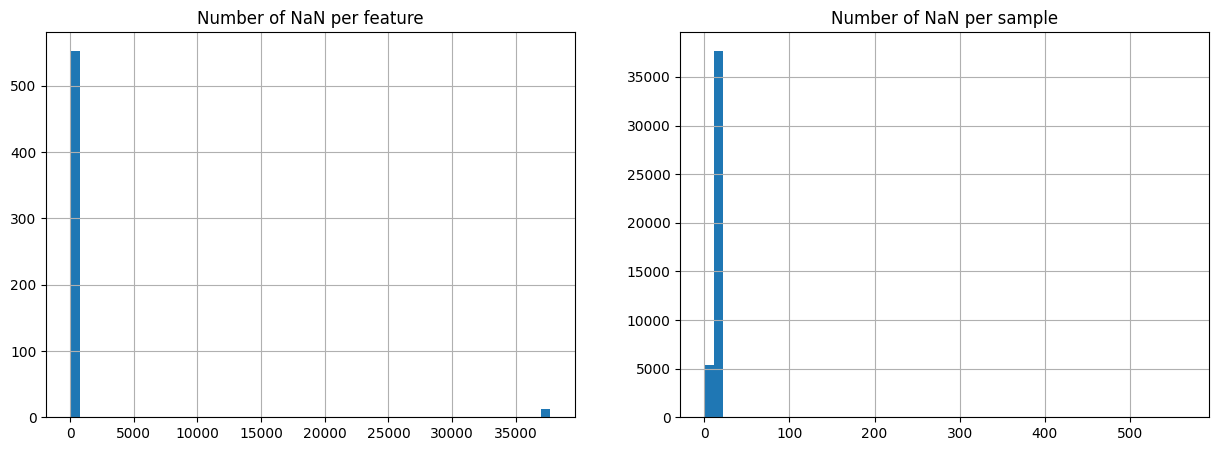

In [37]:
fig, ax = plt.subplots(ncols=2, figsize=(15, 5))
extractions_df.isna().sum(axis=0).hist(bins=50, ax=ax[0])
extractions_df.isna().sum(axis=1).hist(bins=50, ax=ax[1])

ax[0].set_title('Number of NaN per feature')
ax[1].set_title('Number of NaN per sample')

In [13]:
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, IterativeImputer, KNNImputer
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

from umap import UMAP

In [38]:
# add label and demographics
extractions_df['label'] = None
for k in _keys:
    extractions_df.loc[k, 'label'] = res_dict[k]['label']

In [11]:
VAL_COLS = [c for c in extractions_df.columns if c not in ['label', 'segment', 'fs']]

In [ ]:
extractions_df.to_parquet(os.path.join(BASE_DIR, 
                                       'physionet_classification_challenge', 
                                       'extractions_wavelets.parquet'))

In [5]:
extractions_df = pd.read_parquet(os.path.join(BASE_DIR,
                                               'physionet_classification_challenge', 
                                               'extractions_wavelets.parquet'))

In [6]:
dx_map = pd.read_csv(os.path.join(BASE_DIR, 'physionet_classification_challenge', 'Dx_map.csv'))

In [ ]:
le_pipe_euc = Pipeline([
    ('scaler', StandardScaler()),
    ('imputer', IterativeImputer(n_nearest_features=20)),
    ('pca', PCA(n_components=0.95)),
    ('umap', UMAP(n_neighbors=25, min_dist=0.1, metric='manhattan', n_components=2))
])

In [12]:
extractions_2d = le_pipe_euc.fit_transform(extractions_df[VAL_COLS].values)

/media/bramiozo/Storage1/bramiozo/VIRTUALENVS/Python/timex--LThe9rE-py3.12/lib/python3.12/site-packages/sklearn/impute/_iterative.py:825: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [41]:
extractions_2d_df = pd.DataFrame(extractions_2d, columns=['d1', 'd2'])
extractions_2d_df['label'] = extractions_df['label'].values

In [51]:
collected_labels = [ls.split(",") for ls in extractions_2d_df['label'].unique()]
label_set = set()
for ls in collected_labels:
    for l in ls:
        label_set.add(l.strip())

In [78]:
extractions_2d_df[list(label_set)] = False

In [95]:
def get_label_bool(x):
    bool_list = []
    for label in list(label_set):
        if label in x:
            bool_list.append(True)
        else:
            bool_list.append(False)
    return np.array(bool_list)

In [167]:
extractions_2d_df[list(label_set)].sum().sort_values(ascending=False)[:20]

426783006    20846
39732003      6086
164865005     6021
164934002     4673
164873001     3759
428750005     3554
164889003     3475
164951009     3389
164861001     2559
427084000     2402
59118001      2402
270492004     2394
426177001     2359
429622005     1977
164884008     1944
445118002     1806
284470004     1729
713426002     1611
111975006     1513
164930006     1475
dtype: int64

In [116]:
extractions_2d_df.loc[:, list(label_set)] = \
    np.vstack(extractions_2d_df['label'].apply(lambda x: get_label_bool(x)).tolist())

In [152]:
dx_map[dx_map['Dx'].str.contains('cardia', case=False, na=False)].head(10)

,Dx,SNOMED CT Code,Abbreviation
4,acute myocardial infarction,57054005,AMI
5,acute myocardial ischemia,413444003,AMIs
7,anterior myocardial infarction,54329005,AnMI
14,atrial tachycardia,713422000,ATach
19,bradycardia,426627000,Brady
21,cardiac dysrhythmia,698247007,CD
23,chronic myocardial ischemia,413844008,CMI
38,indeterminate cardiac axis,251200008,ICA
43,junctional tachycardia,426648003,JTach
56,myocardial infarction,164865005,MI


In [173]:
dx_map['SNOMED CT Code'] = dx_map['SNOMED CT Code'].astype(str)

In [177]:
dx_map[dx_map['SNOMED CT Code']=='164934002']

,Dx,SNOMED CT Code,Abbreviation
94,t wave abnormal,164934002,TAb


In [168]:
extractions_2d_df['39732003'].value_counts()

39732003
False    37015
True      6086
Name: count, dtype: int64

Text(0.5, 1.0, 'UMAP projection of the ECG features')

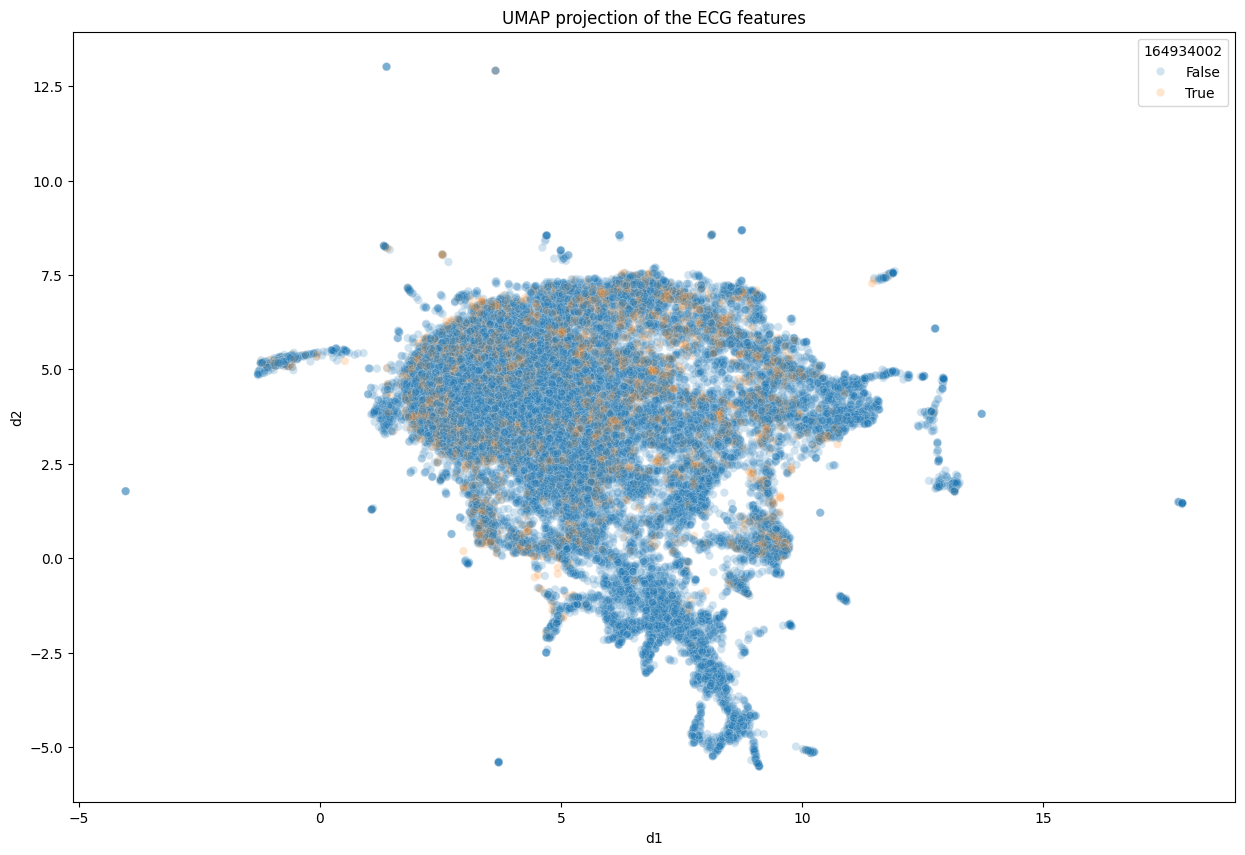

In [178]:
import seaborn as sns
plt.figure(figsize=(15, 10))
sns.scatterplot(data=extractions_2d_df, x='d1', y='d2', hue='164934002', alpha=0.2, hue_order=[False, True])
plt.title('UMAP projection of the ECG features')